# CARD Database Exploration

This notebook explores the Comprehensive Antibiotic Resistance Database (CARD) for AMR prediction modeling.

**Contents:**
1. Load and inspect raw CARD data
2. Analyze drug class distributions
3. Analyze resistance mechanisms
4. Explore sequence characteristics
5. Visualize processed features
6. Baseline model evaluation

In [7]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Paths
CARD_DIR = Path('../data/raw/card-data')
PROCESSED_DIR = Path('../data/processed/card')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Raw CARD Data

In [9]:
# Load ARO index (main gene-drug-mechanism mapping)
aro_index = pd.read_csv(CARD_DIR / 'aro_index.tsv', sep='\t')
print(f"ARO Index: {len(aro_index)} entries")
print(f"Columns: {list(aro_index.columns)}")

ARO Index: 6445 entries
Columns: ['ARO Accession', 'CVTERM ID', 'Model Sequence ID', 'Model ID', 'Model Name', 'ARO Name', 'Protein Accession', 'DNA Accession', 'AMR Gene Family', 'Drug Class', 'Resistance Mechanism', 'CARD Short Name']


In [10]:
aro_index.head()

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id


In [11]:
# Load ARO categories
aro_categories = pd.read_csv(CARD_DIR / 'aro_categories.tsv', sep='\t')
print(f"ARO Categories: {len(aro_categories)} entries")

ARO Categories: 652 entries


In [12]:
aro_categories.head()

,ARO Category,ARO Accession,ARO Name
0,AMR Gene Family,ARO:3004272,16S rRNA methyltransferase (A1408)
1,AMR Gene Family,ARO:3004271,16S rRNA methyltransferase (G1405)
2,AMR Gene Family,ARO:3003666,16s rRNA with mutation conferring resistance t...
3,AMR Gene Family,ARO:3003976,16S rRNA with mutation conferring resistance t...
4,AMR Gene Family,ARO:3003667,16s rRNA with mutation conferring resistance t...


In [13]:
# Basic statistics
print("=== CARD Database Statistics ===")
print(f"Total ARO entries: {len(aro_index)}")
print(f"Unique ARO accessions: {aro_index['ARO Accession'].nunique()}")
print(f"Unique gene families: {aro_index['AMR Gene Family'].nunique()}")
print(f"Unique resistance mechanisms: {aro_index['Resistance Mechanism'].nunique()}")

=== CARD Database Statistics ===
Total ARO entries: 6445
Unique ARO accessions: 6440
Unique gene families: 540
Unique resistance mechanisms: 15


## 2. Drug Class Distribution

In [14]:
# Parse drug classes (some entries have multiple classes separated by ;)
drug_counts = Counter()
for drugs in aro_index['Drug Class'].dropna():
    for drug in drugs.split(';'):
        drug_counts[drug.strip()] += 1

drug_df = pd.DataFrame([
    {'Drug Class': drug, 'Count': count} 
    for drug, count in drug_counts.most_common()
])

print(f"Total unique drug classes: {len(drug_df)}")
drug_df.head(20)

Total unique drug classes: 48


,Drug Class,Count
0,cephalosporin,3422
1,penicillin beta-lactam,3124
2,carbapenem,2600
3,monobactam,1340
4,fluoroquinolone antibiotic,313
5,aminoglycoside antibiotic,312
6,peptide antibiotic,255
7,tetracycline antibiotic,243
8,macrolide antibiotic,223
9,glycopeptide antibiotic,178


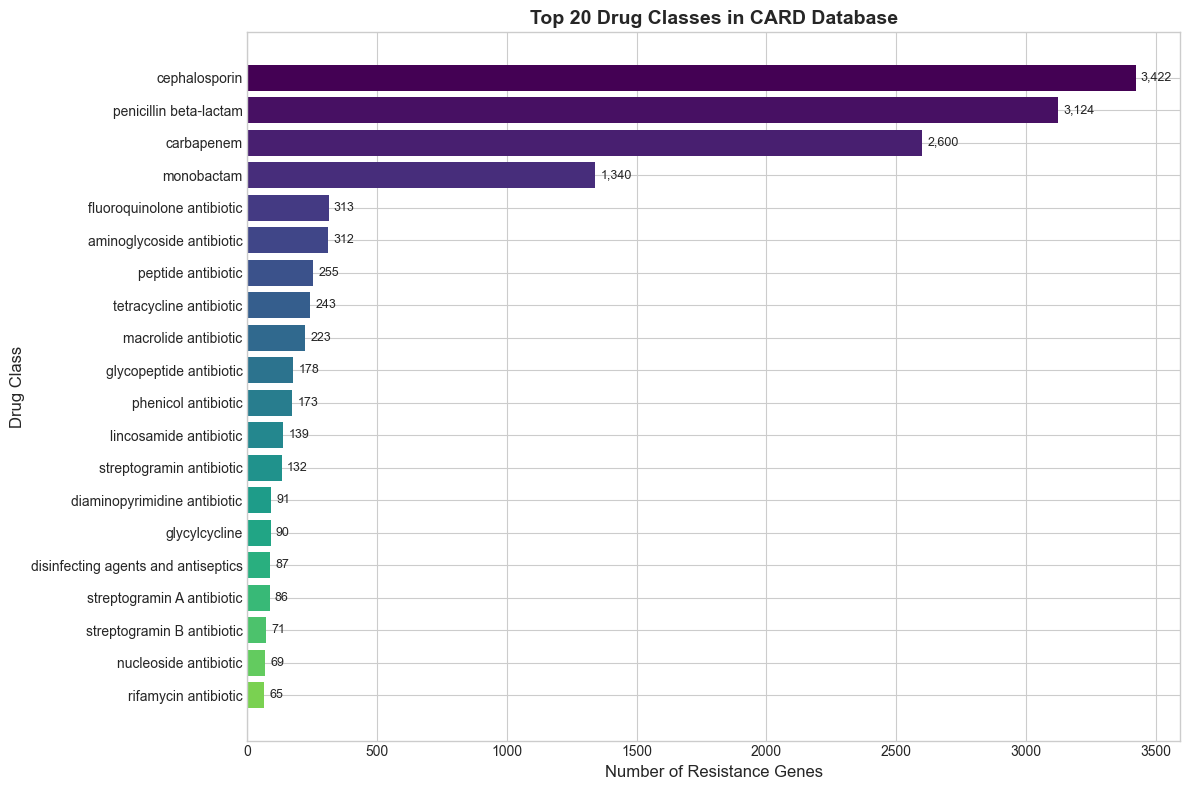

In [15]:
# Visualize top drug classes
fig, ax = plt.subplots(figsize=(12, 8))

top_drugs = drug_df.head(20)
colors = plt.cm.viridis(np.linspace(0, 0.8, len(top_drugs)))

bars = ax.barh(top_drugs['Drug Class'], top_drugs['Count'], color=colors)
ax.set_xlabel('Number of Resistance Genes', fontsize=12)
ax.set_ylabel('Drug Class', fontsize=12)
ax.set_title('Top 20 Drug Classes in CARD Database', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels
for bar, count in zip(bars, top_drugs['Count']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

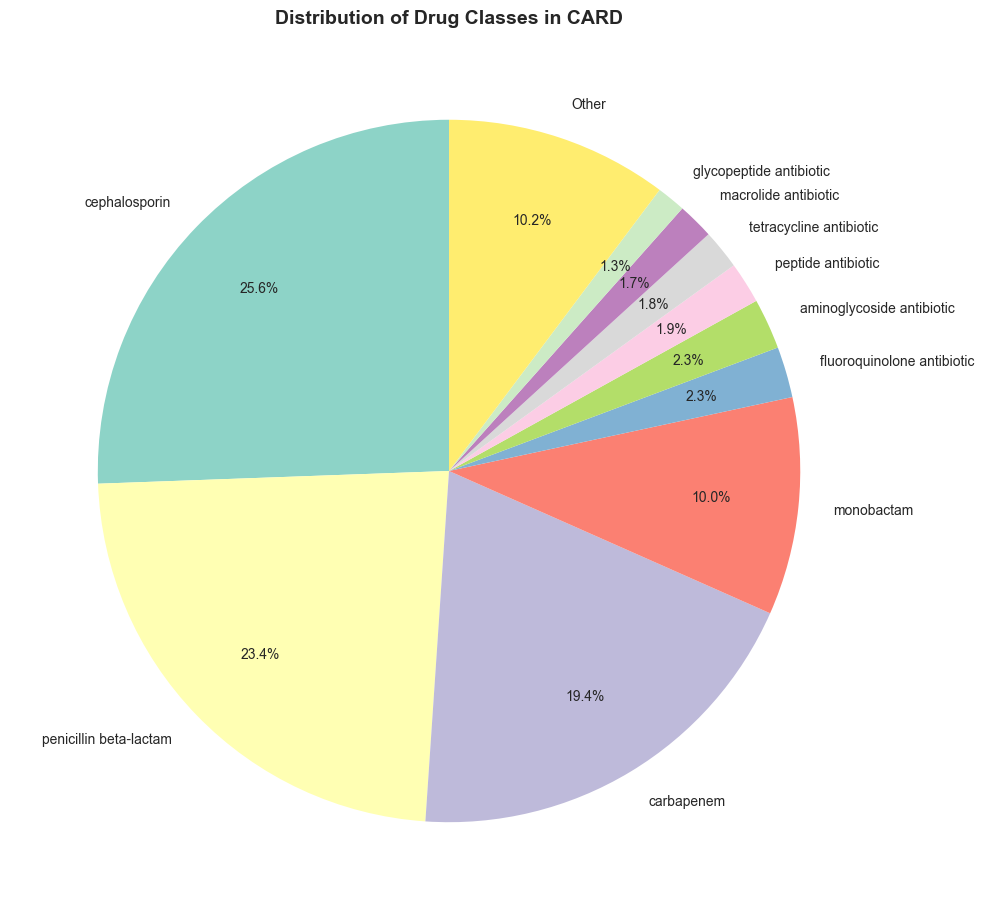

In [16]:
# Drug class distribution (pie chart for major categories)
fig, ax = plt.subplots(figsize=(10, 10))

top_10 = drug_df.head(10).copy()
other_count = drug_df.iloc[10:]['Count'].sum()
top_10 = pd.concat([top_10, pd.DataFrame([{'Drug Class': 'Other', 'Count': other_count}])])

colors = plt.cm.Set3(np.linspace(0, 1, len(top_10)))
wedges, texts, autotexts = ax.pie(
    top_10['Count'], 
    labels=top_10['Drug Class'],
    autopct='%1.1f%%',
    colors=colors,
    pctdistance=0.75,
    startangle=90
)
ax.set_title('Distribution of Drug Classes in CARD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Resistance Mechanism Analysis

In [17]:
# Resistance mechanism distribution
mechanism_counts = aro_index['Resistance Mechanism'].value_counts()
mechanism_df = mechanism_counts.reset_index()
mechanism_df.columns = ['Mechanism', 'Count']

print(f"Unique resistance mechanisms: {len(mechanism_df)}")
mechanism_df

Unique resistance mechanisms: 15


,Mechanism,Count
0,antibiotic inactivation,5245
1,antibiotic target alteration,580
2,antibiotic efflux,296
3,antibiotic target protection,176
4,antibiotic target replacement,71
5,antibiotic efflux;antibiotic target alteration,28
6,reduced permeability to antibiotic,16
7,antibiotic target alteration;antibiotic target...,10
8,reduced permeability to antibiotic;resistance ...,8
9,antibiotic efflux;antibiotic target alteration...,4


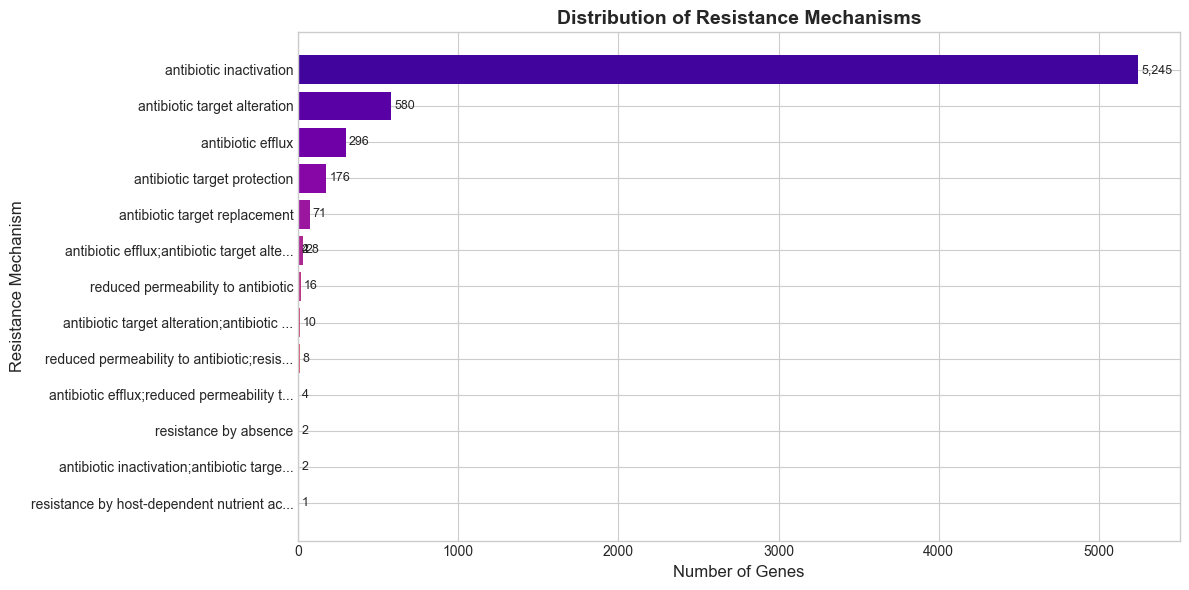

In [18]:
# Visualize resistance mechanisms
fig, ax = plt.subplots(figsize=(12, 6))

# Shorten long mechanism names for display
mechanism_df['Short_Name'] = mechanism_df['Mechanism'].apply(
    lambda x: x[:40] + '...' if len(str(x)) > 40 else x
)

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(mechanism_df)))
bars = ax.barh(mechanism_df['Short_Name'], mechanism_df['Count'], color=colors)

ax.set_xlabel('Number of Genes', fontsize=12)
ax.set_ylabel('Resistance Mechanism', fontsize=12)
ax.set_title('Distribution of Resistance Mechanisms', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels
for bar, count in zip(bars, mechanism_df['Count']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

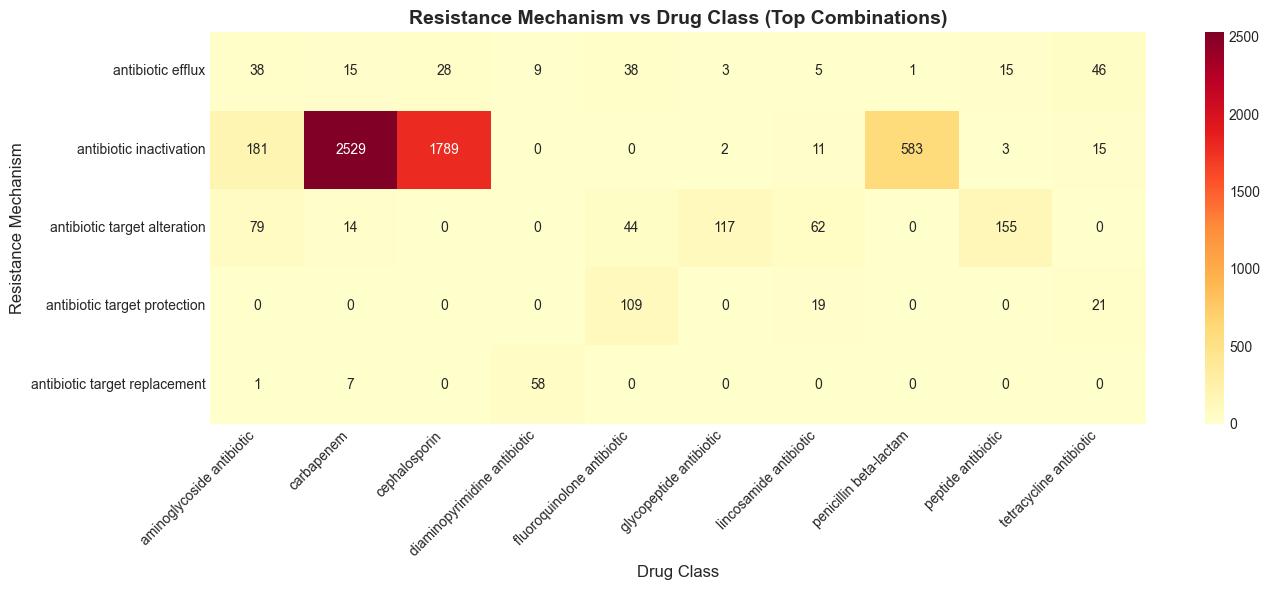

In [19]:
# Mechanism vs Drug Class heatmap (top combinations)
# Create a cross-tabulation
def get_primary_mechanism(mech):
    """Get the first mechanism if multiple are listed."""
    if pd.isna(mech):
        return 'unknown'
    return mech.split(';')[0].strip()

def get_primary_drug(drug):
    """Get the first drug class if multiple are listed."""
    if pd.isna(drug):
        return 'unknown'
    return drug.split(';')[0].strip()

aro_index['Primary_Mechanism'] = aro_index['Resistance Mechanism'].apply(get_primary_mechanism)
aro_index['Primary_Drug'] = aro_index['Drug Class'].apply(get_primary_drug)

# Get top mechanisms and drugs
top_mechanisms = aro_index['Primary_Mechanism'].value_counts().head(5).index.tolist()
top_drugs_list = aro_index['Primary_Drug'].value_counts().head(10).index.tolist()

# Filter and create crosstab
filtered = aro_index[
    (aro_index['Primary_Mechanism'].isin(top_mechanisms)) & 
    (aro_index['Primary_Drug'].isin(top_drugs_list))
]

crosstab = pd.crosstab(filtered['Primary_Mechanism'], filtered['Primary_Drug'])

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Resistance Mechanism vs Drug Class (Top Combinations)', fontsize=14, fontweight='bold')
ax.set_xlabel('Drug Class', fontsize=12)
ax.set_ylabel('Resistance Mechanism', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. AMR Gene Family Analysis

In [20]:
# Gene family distribution
family_counts = aro_index['AMR Gene Family'].value_counts()
print(f"Total unique gene families: {len(family_counts)}")
print(f"\nTop 20 gene families:")
family_counts.head(20)

Total unique gene families: 540

Top 20 gene families:


AMR Gene Family
PDC beta-lactamase                                                       639
OXA beta-lactamase;OXA-51-like beta-lactamase                            383
ADC beta-lactamases pending classification for carbapenemase activity    274
CTX-M beta-lactamase                                                     267
KPC beta-lactamase                                                       229
SHV beta-lactamase                                                       218
TEM beta-lactamase                                                       216
CMY beta-lactamase                                                       195
ACT beta-lactamase                                                       172
resistance-nodulation-cell division (RND) antibiotic efflux pump         127
major facilitator superfamily (MFS) antibiotic efflux pump               118
quinolone resistance protein (qnr)                                       109
MCR phosphoethanolamine transferase                         

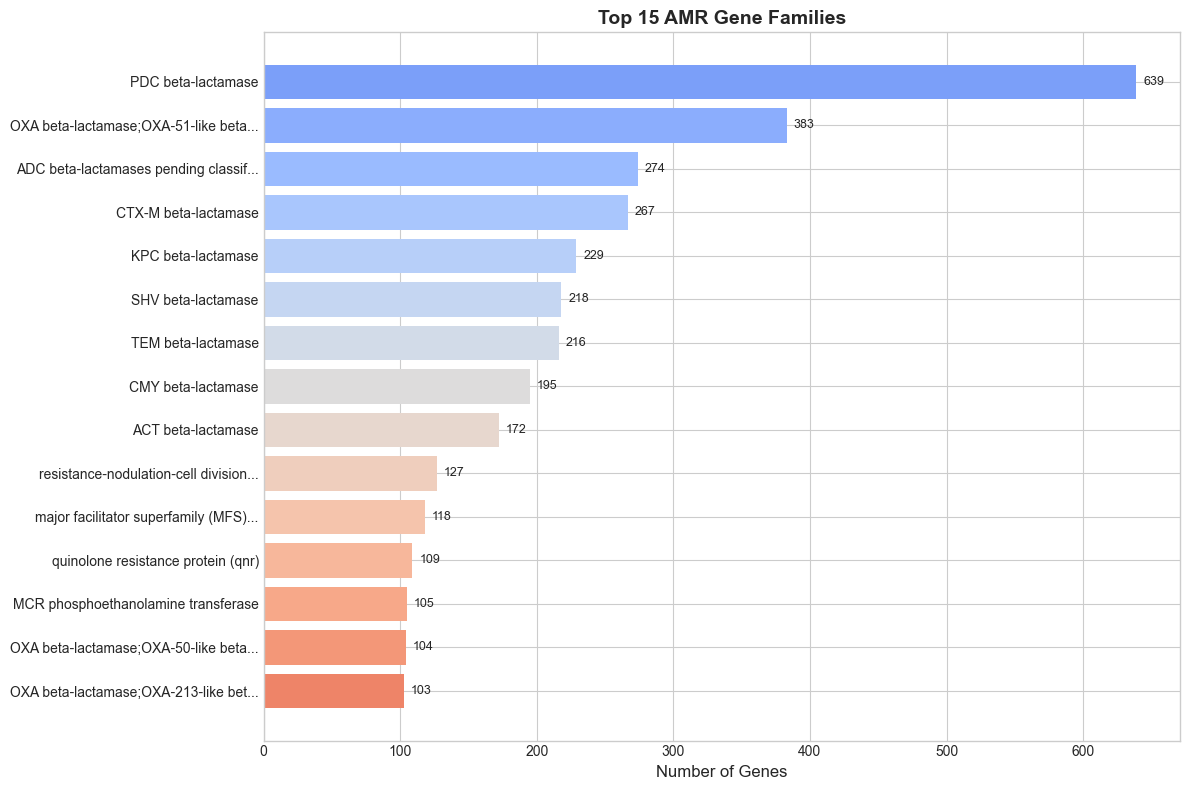

In [21]:
# Visualize top gene families
fig, ax = plt.subplots(figsize=(12, 8))

top_families = family_counts.head(15)
colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(top_families)))

bars = ax.barh(range(len(top_families)), top_families.values, color=colors)
ax.set_yticks(range(len(top_families)))
ax.set_yticklabels([f[:35] + '...' if len(f) > 35 else f for f in top_families.index])
ax.set_xlabel('Number of Genes', fontsize=12)
ax.set_title('Top 15 AMR Gene Families', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, count in zip(bars, top_families.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Explore Processed Features

In [22]:
# Load processed data
X_train = np.load(PROCESSED_DIR / 'card_drug_class_X_train.npy')
X_test = np.load(PROCESSED_DIR / 'card_drug_class_X_test.npy')
y_train = np.load(PROCESSED_DIR / 'card_drug_class_y_train.npy')
y_test = np.load(PROCESSED_DIR / 'card_drug_class_y_test.npy')

with open(PROCESSED_DIR / 'card_drug_class_metadata.json', 'r') as f:
    metadata = json.load(f)

print("=== Processed Data Statistics ===")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features (k-mers): {X_train.shape[1]}")
print(f"Number of drug classes: {y_train.shape[1]}")
print(f"Task type: {metadata['task_type']}")

=== Processed Data Statistics ===
Training samples: 4237
Test samples: 1211
Number of features (k-mers): 500
Number of drug classes: 38
Task type: multilabel


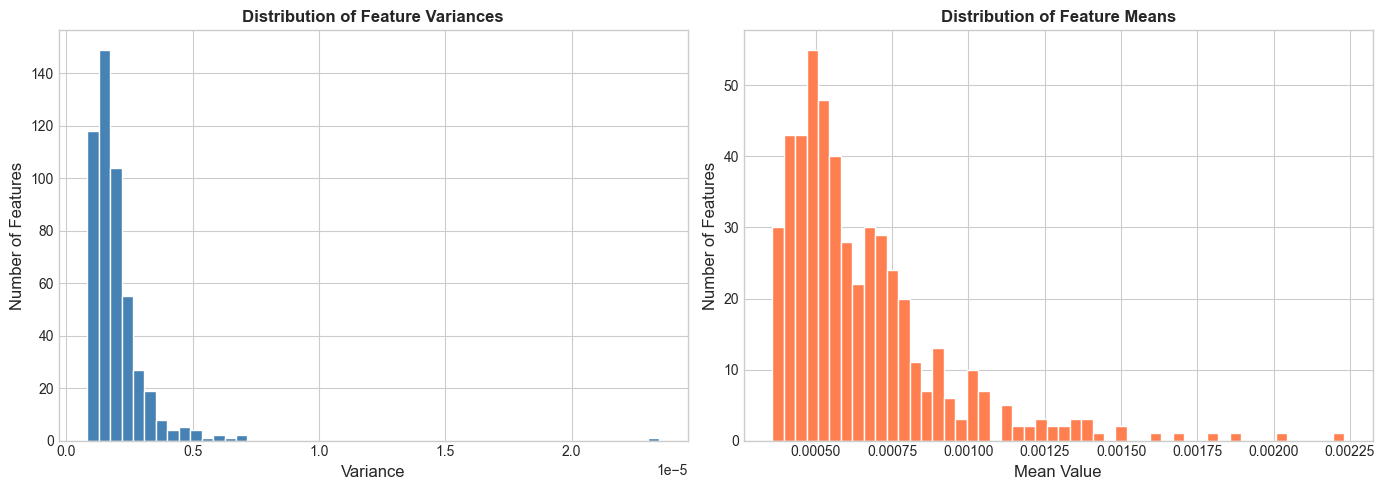

In [23]:
# Feature distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature variance
feature_var = np.var(X_train, axis=0)
axes[0].hist(feature_var, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Variance', fontsize=12)
axes[0].set_ylabel('Number of Features', fontsize=12)
axes[0].set_title('Distribution of Feature Variances', fontsize=12, fontweight='bold')

# Feature means
feature_mean = np.mean(X_train, axis=0)
axes[1].hist(feature_mean, bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('Mean Value', fontsize=12)
axes[1].set_ylabel('Number of Features', fontsize=12)
axes[1].set_title('Distribution of Feature Means', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

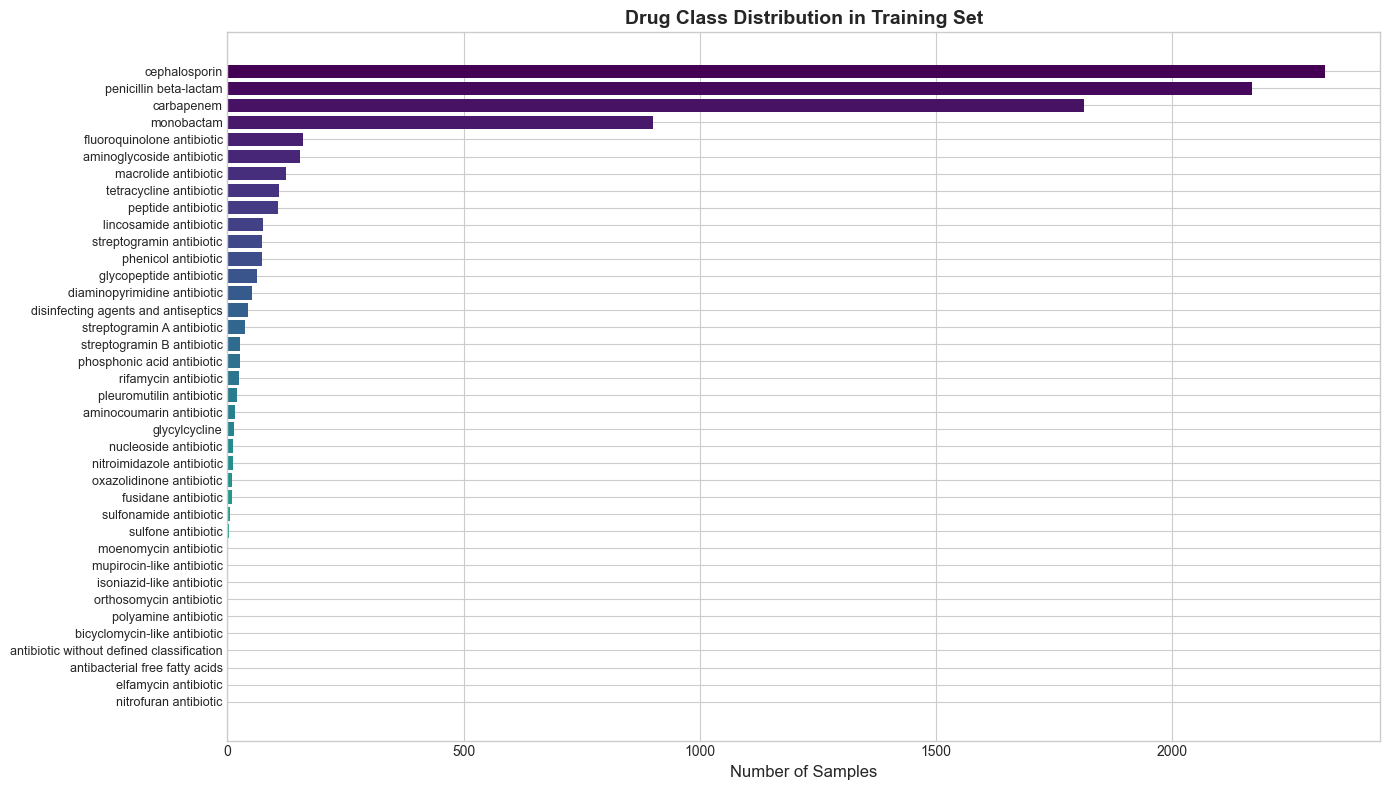

In [24]:
# Label distribution (drug classes)
class_names = metadata['class_names']
label_counts = y_train.sum(axis=0)

fig, ax = plt.subplots(figsize=(14, 8))

sorted_idx = np.argsort(label_counts)[::-1]
sorted_counts = label_counts[sorted_idx]
sorted_names = [class_names[i] for i in sorted_idx]

colors = plt.cm.viridis(np.linspace(0, 0.8, len(sorted_counts)))
bars = ax.barh(range(len(sorted_counts)), sorted_counts, color=colors)
ax.set_yticks(range(len(sorted_counts)))
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('Number of Samples', fontsize=12)
ax.set_title('Drug Class Distribution in Training Set', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

Average drug classes per gene: 2.00
Max drug classes per gene: 13
Min drug classes per gene: 1


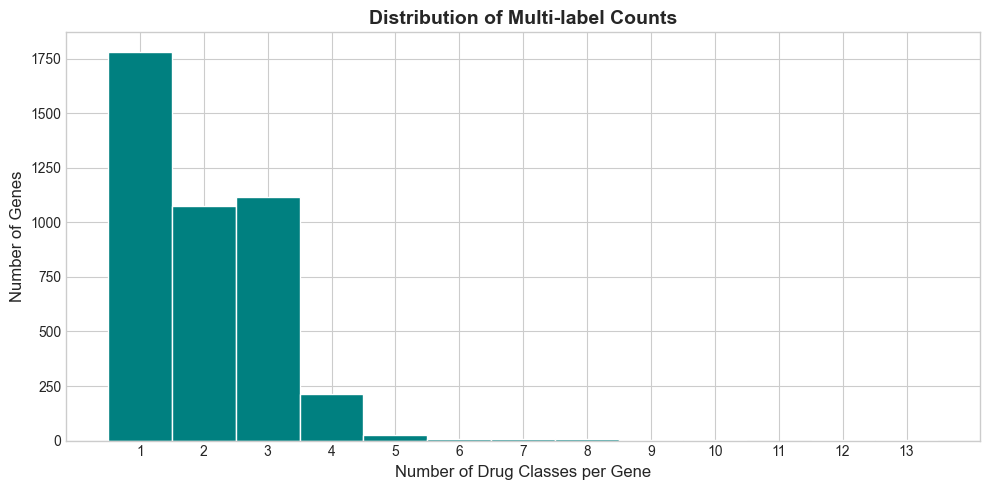

In [25]:
# Multi-label statistics
labels_per_sample = y_train.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(labels_per_sample, bins=range(1, int(labels_per_sample.max()) + 2), 
        color='teal', edgecolor='white', align='left')
ax.set_xlabel('Number of Drug Classes per Gene', fontsize=12)
ax.set_ylabel('Number of Genes', fontsize=12)
ax.set_title('Distribution of Multi-label Counts', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, int(labels_per_sample.max()) + 1))

print(f"Average drug classes per gene: {labels_per_sample.mean():.2f}")
print(f"Max drug classes per gene: {labels_per_sample.max():.0f}")
print(f"Min drug classes per gene: {labels_per_sample.min():.0f}")

plt.tight_layout()
plt.show()

## 6. Feature Correlation Analysis

In [26]:
# Top k-mer features by variance
feature_names = metadata['feature_names']
top_var_idx = np.argsort(feature_var)[::-1][:20]

print("Top 20 most variable k-mer features:")
for i, idx in enumerate(top_var_idx, 1):
    print(f"{i:2d}. {feature_names[idx]}: variance = {feature_var[idx]:.6f}")

Top 20 most variable k-mer features:
 1. AAA: variance = 0.000023
 2. IGL: variance = 0.000007
 3. ALA: variance = 0.000007
 4. GLE: variance = 0.000006
 5. ISL: variance = 0.000006
 6. AAV: variance = 0.000006
 7. AST: variance = 0.000005
 8. LAR: variance = 0.000005
 9. PAS: variance = 0.000005
10. YGN: variance = 0.000005
11. LLT: variance = 0.000005
12. DLA: variance = 0.000005
13. AAL: variance = 0.000005
14. LAA: variance = 0.000005
15. NTA: variance = 0.000005
16. LLL: variance = 0.000004
17. LAE: variance = 0.000004
18. LLA: variance = 0.000004
19. SAI: variance = 0.000004
20. LEQ: variance = 0.000004


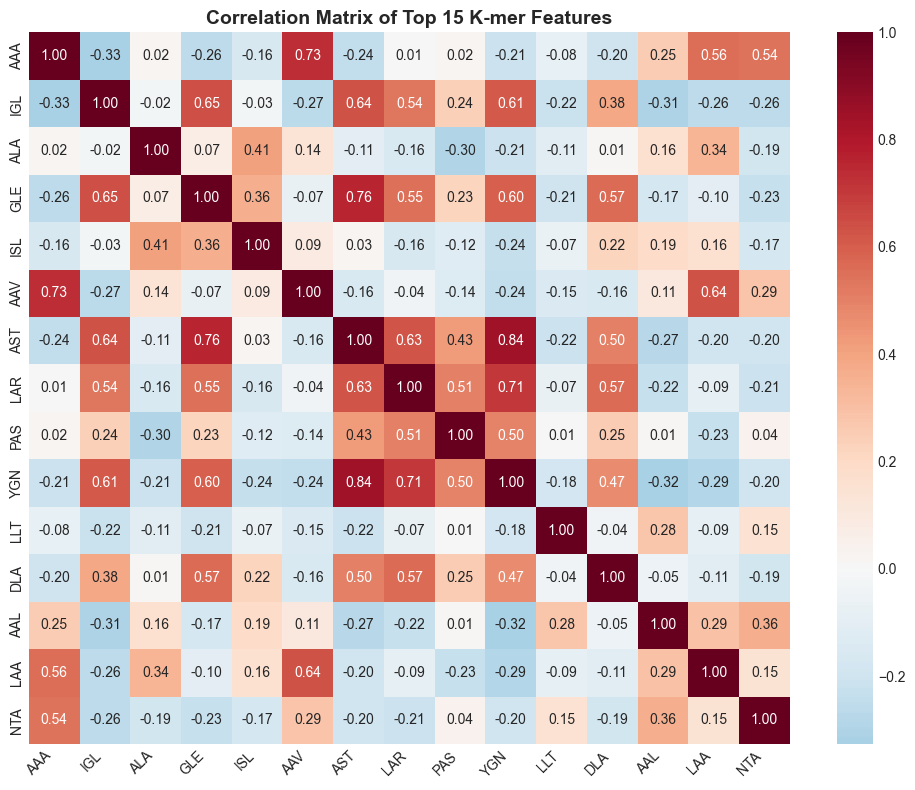

In [27]:
# Correlation heatmap of top features
top_features = X_train[:, top_var_idx[:15]]
top_feature_names = [feature_names[i] for i in top_var_idx[:15]]

corr_matrix = np.corrcoef(top_features.T)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=top_feature_names, yticklabels=top_feature_names, ax=ax)
ax.set_title('Correlation Matrix of Top 15 K-mer Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Dimensionality Reduction Visualization

In [28]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

PCA explained variance ratio: [0.16514071 0.13257456]
Total variance explained: 29.77%


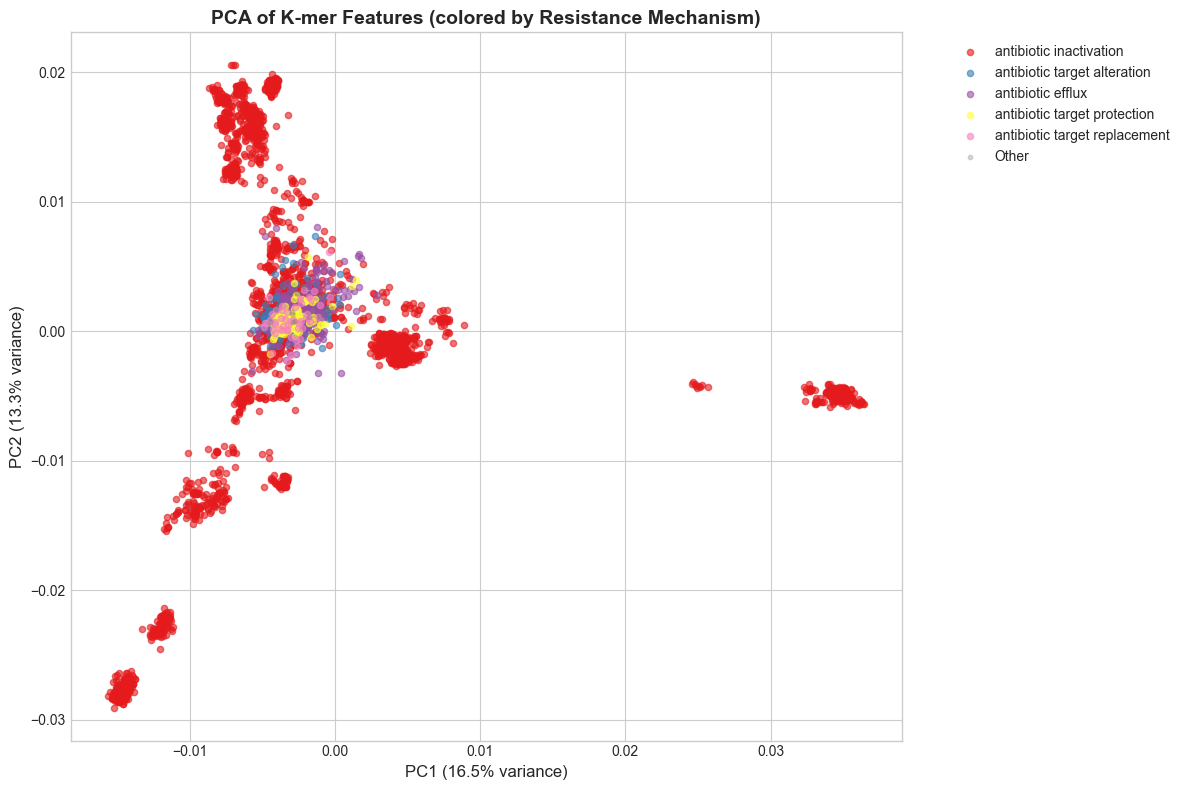

In [29]:
# Color by primary resistance mechanism
# Load mechanism labels
y_mech_train = np.load(PROCESSED_DIR / 'card_mechanism_y_train.npy')
with open(PROCESSED_DIR / 'card_mechanism_metadata.json', 'r') as f:
    mech_metadata = json.load(f)

mech_names = mech_metadata['class_names']

fig, ax = plt.subplots(figsize=(12, 8))

# Use top 5 mechanisms for coloring
unique_mechs = np.unique(y_mech_train)
mech_counts = [(m, (y_mech_train == m).sum()) for m in unique_mechs]
top_mechs = sorted(mech_counts, key=lambda x: x[1], reverse=True)[:5]
top_mech_ids = [m[0] for m in top_mechs]

colors = plt.cm.Set1(np.linspace(0, 1, len(top_mech_ids) + 1))

for i, mech_id in enumerate(top_mech_ids):
    mask = y_mech_train == mech_id
    mech_name = mech_names[mech_id][:30] + '...' if len(mech_names[mech_id]) > 30 else mech_names[mech_id]
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[i]], label=mech_name, alpha=0.6, s=20)

# Plot others
other_mask = ~np.isin(y_mech_train, top_mech_ids)
ax.scatter(X_pca[other_mask, 0], X_pca[other_mask, 1], c='gray', label='Other', alpha=0.3, s=10)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('PCA of K-mer Features (colored by Resistance Mechanism)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 8. Baseline Model Evaluation

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, f1_score, hamming_loss

# Load validation data
X_val = np.load(PROCESSED_DIR / 'card_drug_class_X_val.npy')
y_val = np.load(PROCESSED_DIR / 'card_drug_class_y_val.npy')

print("Training baseline Random Forest model...")
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Training baseline Random Forest model...
Training samples: 4237
Validation samples: 606


In [31]:
# Train a simple Random Forest for multi-label classification
rf = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
)

rf.fit(X_train, y_train)
print("Model trained!")

/opt/miniconda3/lib/python3.13/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 9 is present in all training examples.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 20 is present in all training examples.
  warnings.warn(


Model trained!


In [32]:
# Evaluate on validation set
y_val_pred = rf.predict(X_val)

print("=== Validation Set Performance ===")
print(f"Hamming Loss: {hamming_loss(y_val, y_val_pred):.4f}")
print(f"Micro F1: {f1_score(y_val, y_val_pred, average='micro'):.4f}")
print(f"Macro F1: {f1_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_val, y_val_pred, average='weighted'):.4f}")

=== Validation Set Performance ===
Hamming Loss: 0.0088
Micro F1: 0.9095
Macro F1: 0.2376
Weighted F1: 0.8733


/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [33]:
# Evaluate on test set
y_test_pred = rf.predict(X_test)

print("=== Test Set Performance ===")
print(f"Hamming Loss: {hamming_loss(y_test, y_test_pred):.4f}")
print(f"Micro F1: {f1_score(y_test, y_test_pred, average='micro'):.4f}")
print(f"Macro F1: {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

=== Test Set Performance ===
Hamming Loss: 0.0096
Micro F1: 0.9014
Macro F1: 0.2203
Weighted F1: 0.8587


/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


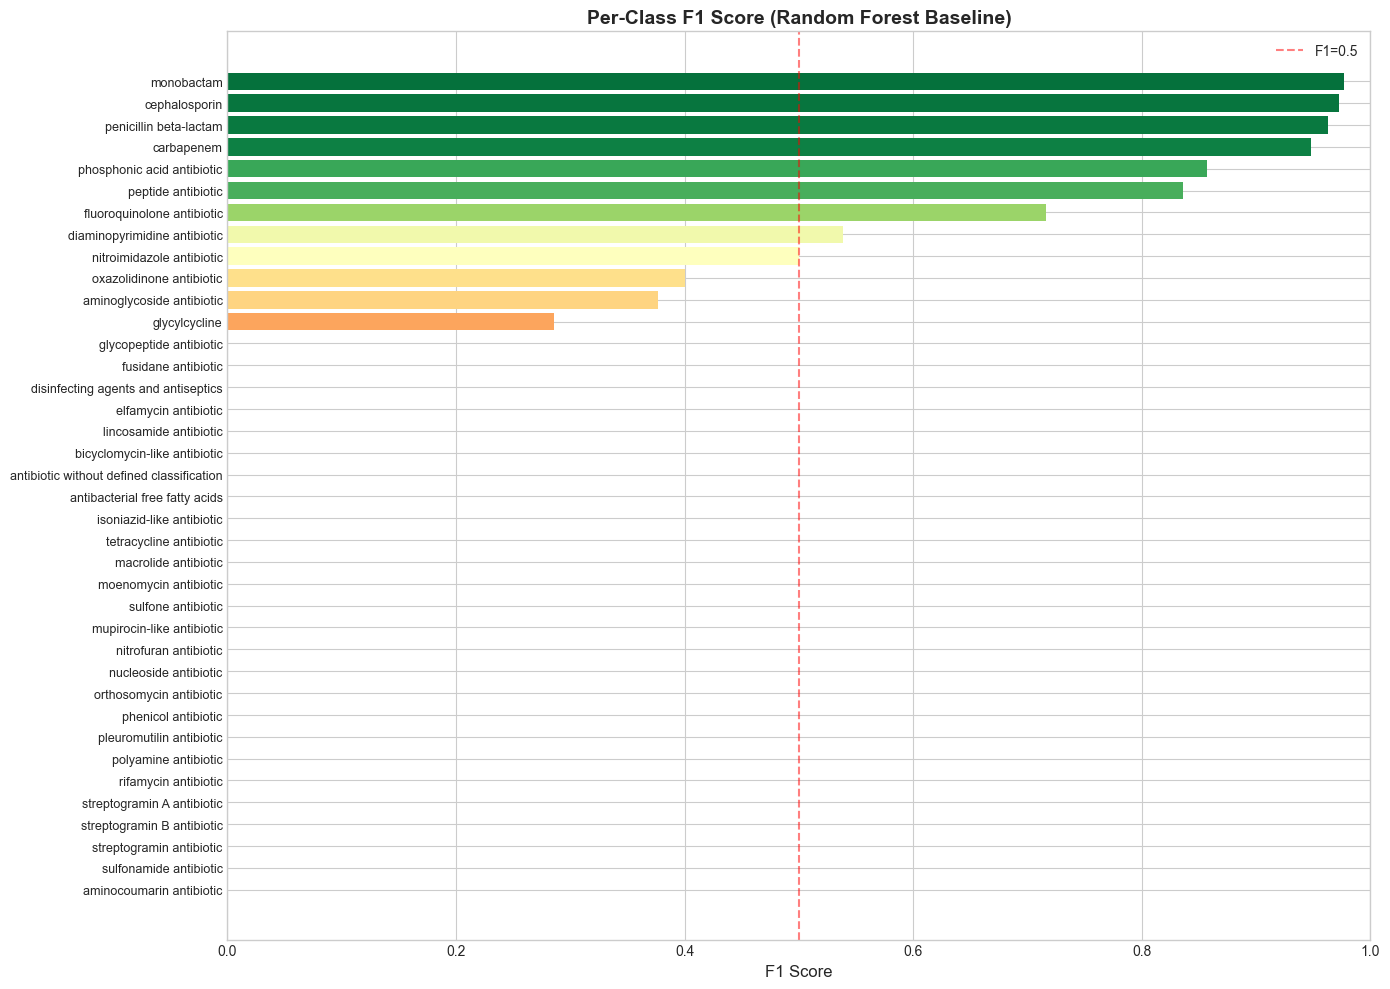

In [34]:
# Per-class performance
per_class_f1 = f1_score(y_test, y_test_pred, average=None)

# Sort by F1 score
sorted_idx = np.argsort(per_class_f1)[::-1]

fig, ax = plt.subplots(figsize=(14, 10))

colors = plt.cm.RdYlGn(per_class_f1[sorted_idx])
bars = ax.barh(range(len(class_names)), per_class_f1[sorted_idx], color=colors)
ax.set_yticks(range(len(class_names)))
ax.set_yticklabels([class_names[i] for i in sorted_idx], fontsize=9)
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title('Per-Class F1 Score (Random Forest Baseline)', fontsize=14, fontweight='bold')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='F1=0.5')
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

## Summary

### Key Findings:

1. **Dataset Size**: 6,445 ARO entries with 6,054 having protein sequences

2. **Drug Classes**: 38 unique drug classes, dominated by:
   - Beta-lactams (cephalosporin, penicillin, carbapenem, monobactam)
   - Aminoglycosides and fluoroquinolones

3. **Resistance Mechanisms**: 10 main mechanisms, with "antibiotic inactivation" being the most common (87%)

4. **Gene Families**: 398 unique gene families

5. **Features**: 500 3-mer frequency features from protein sequences

6. **Baseline Performance**: Random Forest achieves reasonable F1 scores, with better performance on common drug classes

### Next Steps:
- Train deep learning models (CNN, RNN, Transformer)
- Use sequence embeddings (ESM, ProtTrans)
- Handle class imbalance
- Integrate with genome-level features